The Geometry of Detour: Comparing Euclidean and Network Distance in Manhattan’s Grid and Diagonal Matrix


Urban mobility is fundamentally shaped by the underlying geometry of the city. While Manhattan is globally renowned for its rigid orthogonal commissioner's grid, the diagonal trajectory of Broadway cuts across this uniform matrix, creating unique spatial friction, focal nodes, and experiential transitions. This study investigates the divergence between Euclidean distance (as-the-crow-flies straight-line distance) and actual network distance (shortest path routing along the pedestrian street network) across key urban nodes intersecting both the standard grid and diagonal corridors.

By defining the pedestrian street network as a topological graph, this notebook measures the precise physical and psychological "detour cost" imposed by the built environment. Ultimately, this research reflects on how architectural alignments and urban planning geometries reshape human spatial perception, walkability, and the everyday experience of navigating the metropolis.

In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from shapely.geometry import LineString, MultiLineString, Point, Polygon
import pandas as pd
import requests
import networkx as nx
import osmnx as ox
import h3
import libpysal as lps
import numpy as np

In [2]:
from cdptools import utils

In [3]:
utils.set_axis_off()

In [4]:
# bounding box of nyc
bbox = (-74.3, 40.5, -73.7, 40.9)

## Defining Core Analysis Nodes

select specific key urban intersections and nodes in Manhattan that capture the intersection of the rigid commissioner's grid and the diagonal path of Broadway (e.g., Union Square, Madison Square, Herald Square, and Times Square).

In [5]:
from shapely.geometry import Point
import geopandas as pd
import pandas as pd

In [6]:
nodes_data = [
    {"name": "Union Square", "lon": -73.9904, "lat": 40.7359},
    {"name": "Madison Square", "lon": -73.9877, "lat": 40.7420},
    {"name": "Herald Square", "lon": -73.9875, "lat": 40.7501},
    {"name": "Times Square", "lon": -73.9851, "lat": 40.7580},
]

In [7]:
df = pd.DataFrame(nodes_data)
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df.lon, df.lat), crs="EPSG:4326")

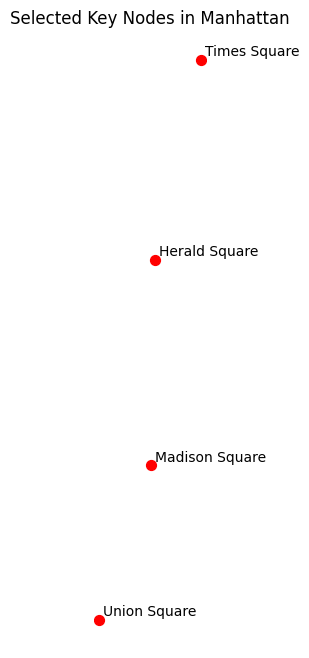

In [8]:
ax = gdf.plot(color="red", markersize=50, figsize=(8, 8))
gdf.apply(
    lambda x: ax.annotate(
        text=x["name"],
        xy=(x.geometry.x, x.geometry.y),
        xytext=(3, 3),
        textcoords="offset points",
    ),
    axis=1,
)
plt.title("Selected Key Nodes in Manhattan")
plt.show()

In [9]:
k = 3
neighbors = gdf.geometry.apply(lambda x: gdf.geometry.distance(x)).values.argsort(
    axis=1
)[:, 1 : k + 1]

# join neighbors to original dataframe
gdf["neighbors"] = neighbors.tolist()

/var/folders/y7/s35ppzz53939b38v0wh9wm3m0000gn/T/ipykernel_24215/4023346015.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  neighbors = gdf.geometry.apply(lambda x: gdf.geometry.distance(x)).values.argsort(


In [10]:
gdf.neighbors

0    [1, 2, 3]
1    [0, 2, 3]
2    [1, 3, 0]
3    [2, 1, 0]
Name: neighbors, dtype: object

Now if we inspect our dataframe, we see that we have an additional column, `neighbors`, which contains the row index number of the five nearest points to that row.

In [11]:
gdf.head(5)

,name,lon,lat,geometry,neighbors
0,Union Square,-73.9904,40.7359,POINT (-73.9904 40.7359),"[1, 2, 3]"
1,Madison Square,-73.9877,40.7420,POINT (-73.9877 40.742),"[0, 2, 3]"
2,Herald Square,-73.9875,40.7501,POINT (-73.9875 40.7501),"[1, 3, 0]"
3,Times Square,-73.9851,40.7580,POINT (-73.9851 40.758),"[2, 1, 0]"


In [12]:
def create_lines(r):
    lines = []
    for i, neighbor in enumerate(r.neighbors):
        lines.append(LineString([r.geometry, gdf.loc[neighbor].geometry]))
    return MultiLineString(lines)

In [13]:
gdf["line_geometry"] = gdf.apply(create_lines, axis=1)

In [14]:
gdf.head()

,name,lon,lat,geometry,neighbors,line_geometry
0,Union Square,-73.9904,40.7359,POINT (-73.9904 40.7359),"[1, 2, 3]","MULTILINESTRING ((-73.9904 40.7359, -73.9877 4..."
1,Madison Square,-73.9877,40.7420,POINT (-73.9877 40.742),"[0, 2, 3]","MULTILINESTRING ((-73.9877 40.742, -73.9904 40..."
2,Herald Square,-73.9875,40.7501,POINT (-73.9875 40.7501),"[1, 3, 0]","MULTILINESTRING ((-73.9875 40.7501, -73.9877 4..."
3,Times Square,-73.9851,40.7580,POINT (-73.9851 40.758),"[2, 1, 0]","MULTILINESTRING ((-73.9851 40.758, -73.9875 40..."


In [15]:
lines_gdf = gpd.GeoDataFrame(
    gdf[["line_geometry"]], geometry="line_geometry", crs="EPSG:4326"
)

<Axes: >

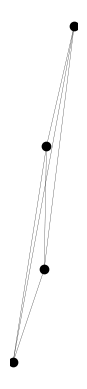

In [16]:
ax = lines_gdf.plot(color="black", alpha=0.5, linewidth=0.2)
gdf.plot(ax=ax, color="black")

# optionally save the figure to file
# plt.savefig("lines.pdf", bbox_inches="tight", pad_inches=0)

In [17]:
gdf["geometry"].to_file("nodes.geojson", driver="GeoJSON")
gdf["line_geometry"].to_file("edges.geojson", driver="GeoJSON")

/opt/miniconda3/envs/mapping_system_cdp_jay/lib/python3.12/site-packages/pyogrio/geopandas.py:917: UserWarning: 'crs' was not provided.  The output dataset will not have projection information defined and may not be usable in other systems.
  write(


In [19]:
gdf.sample(4)

,name,lon,lat,geometry,neighbors,line_geometry
2,Herald Square,-73.9875,40.7501,POINT (-73.9875 40.7501),"[1, 3, 0]","MULTILINESTRING ((-73.9875 40.7501, -73.9877 4..."
1,Madison Square,-73.9877,40.7420,POINT (-73.9877 40.742),"[0, 2, 3]","MULTILINESTRING ((-73.9877 40.742, -73.9904 40..."
3,Times Square,-73.9851,40.7580,POINT (-73.9851 40.758),"[2, 1, 0]","MULTILINESTRING ((-73.9851 40.758, -73.9875 40..."
0,Union Square,-73.9904,40.7359,POINT (-73.9904 40.7359),"[1, 2, 3]","MULTILINESTRING ((-73.9904 40.7359, -73.9877 4..."


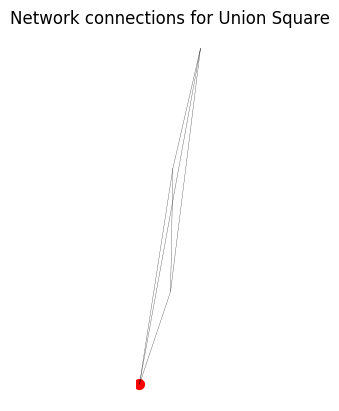

In [20]:
s = gdf.iloc[[0]]
ax = lines_gdf.plot(color="black", alpha=0.5, linewidth=0.2)
s.plot(ax=ax, color="red", markersize=50)
plt.title("Network connections for Union Square")
plt.show()

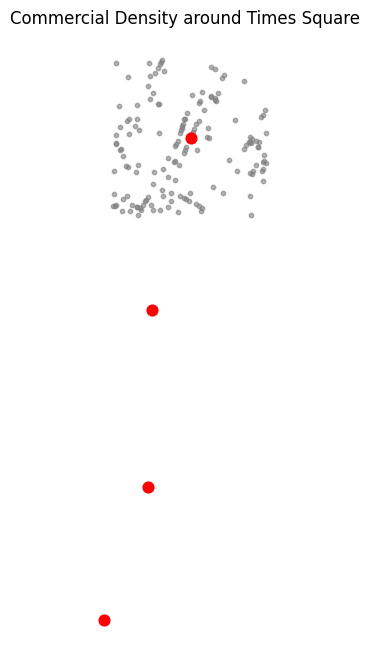

In [27]:
tags = {"shop": True}
commercial_gdf = ox.features_from_point((40.7580, -73.9851), tags=tags, dist=400)

commercial_gdf = commercial_gdf[commercial_gdf.geometry.type == "Point"]

ax = commercial_gdf.plot(color="gray", markersize=10, alpha=0.6, figsize=(8, 8))
gdf.plot(ax=ax, color="red", markersize=60)
plt.title("Commercial Density around Times Square")
plt.show()

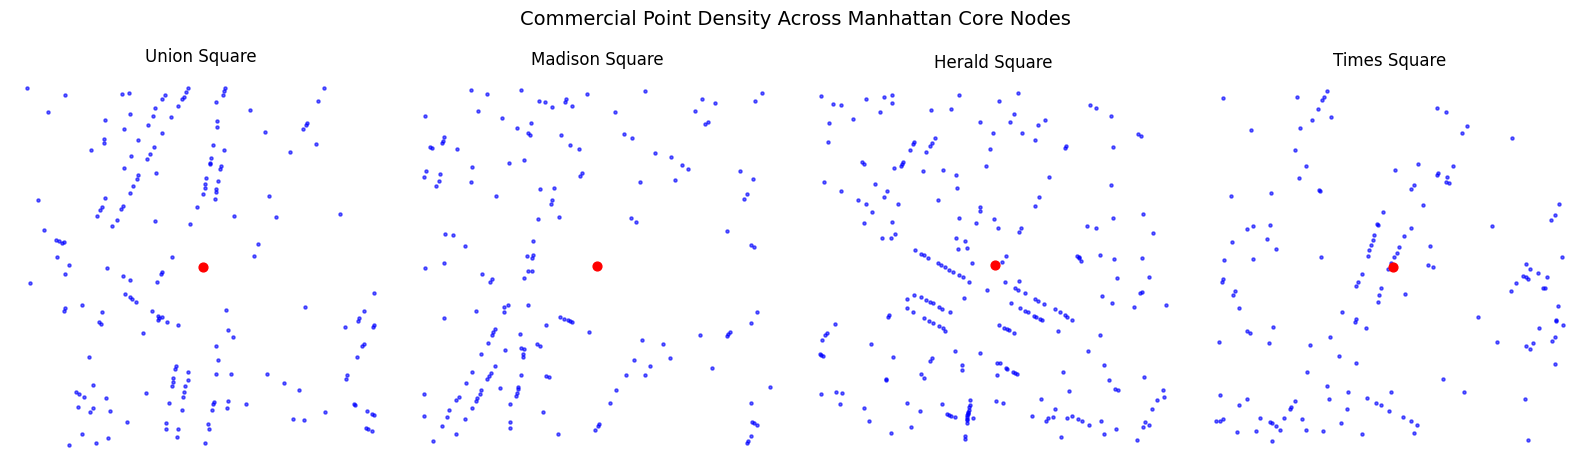

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for idx, (i, row) in enumerate(gdf.iterrows()):
    point_lat_lon = (row["lat"], row["lon"])
    name = row["name"]

    ax = axes[idx]
    try:
        tags = {"shop": True}
        shops_gdf = ox.features_from_point(point_lat_lon, tags=tags, dist=400)
        shops_gdf = shops_gdf[shops_gdf.geometry.type == "Point"]
        shops_gdf.plot(
            ax=ax, color="blue", markersize=5, alpha=0.6
        )  # 抓到的商店（蓝点）
    except Exception as e:
        print(f"Note for {name}: {e}")

    gdf.loc[[i]].plot(ax=ax, color="red", markersize=40)
    ax.set_title(name)
    ax.set_axis_off()

plt.suptitle("Commercial Point Density Across Manhattan Core Nodes", fontsize=14)
plt.tight_layout()
plt.show()

In [35]:
G = ox.graph_from_point((40.7580, -73.9851), dist=500, network_type="walk")

_, edges = ox.graph_to_gdfs(G)

In [36]:
cols_to_show = [
    c for c in ["name", "shop", "amenity", "geometry"] if c in commercial_gdf.columns
]

df_table = commercial_gdf[cols_to_show].head(10).copy()

df_table["longitude"] = df_table.geometry.x
df_table["latitude"] = df_table.geometry.y

df_display = df_table.drop(columns="geometry", errors="ignore")

display(df_display)

name           shop amenity  \
element id                                                             
node    1426276157                       AT&T   mobile_phone     NaN   
        1606745845                        NaN         vacant     NaN   
        1751769863               NY Gift Shop           gift     NaN   
        2178743031                   Skechers          shoes     NaN   
        2610440244                       Loft        clothes     NaN   
        2613556157               Ralph Lauren        clothes     NaN   
        2613887631  American Eagle Outfitters        clothes     NaN   
        2678466844                        Gap        clothes     NaN   
        2678783480                M&M'S World  confectionery     NaN   
        2689589692                    Express        clothes     NaN   

                    longitude   latitude  
element id                                
node    1426276157 -73.986793  40.756593  
        1606745845 -73.985424  40.755206  
        1751769863 -73.988238  40.758373  
        2178743031 -73.987325  40.756417  
        2610440244 -73.986863  40.755591  
        2613556157 -73.988778  40.754670  
        2613887631 -73.985491  40.758865  
        2678466844 -73.985506  40.757300  
        2678783480 -73.984417  40.760091  
        2689589692 -73.984814  40.758626

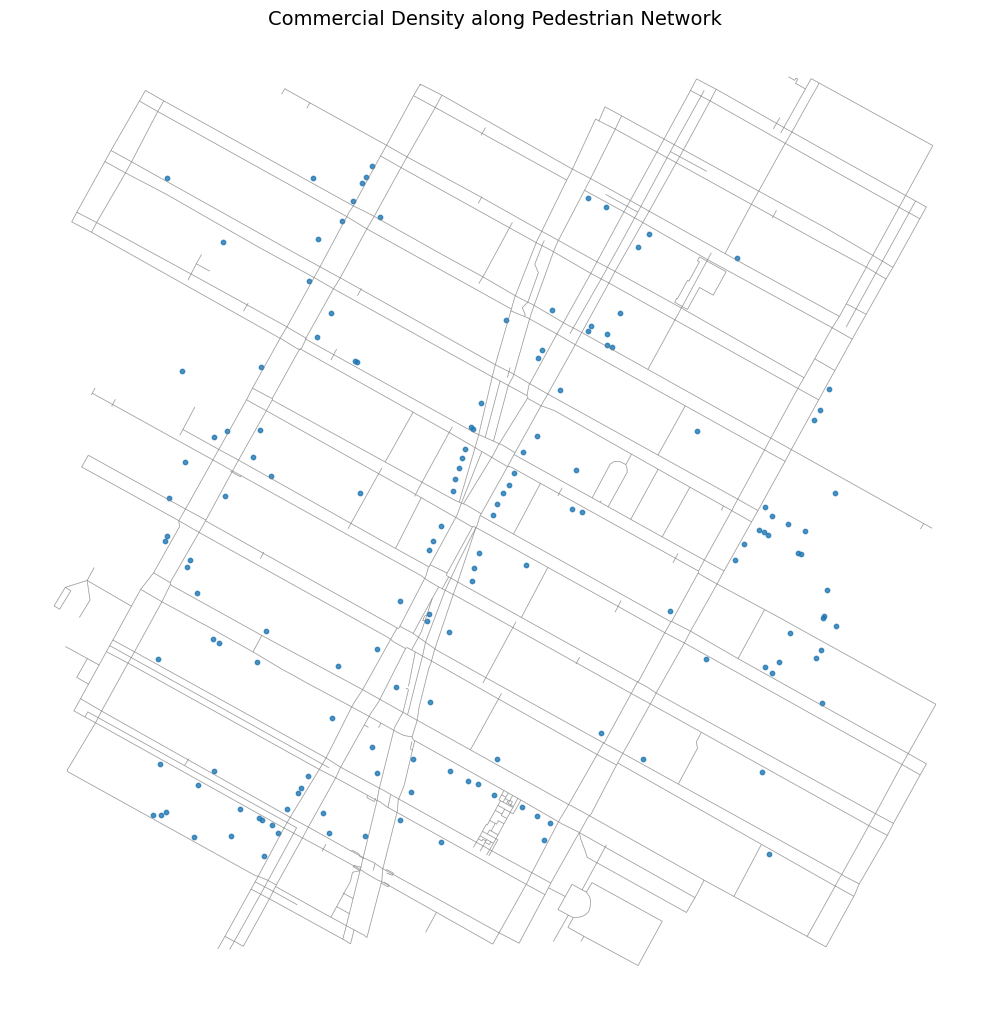

In [37]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
edges.plot(ax=ax, color="gray", linewidth=0.5, alpha=0.5)
commercial_gdf.plot(ax=ax, color="#1f77b4", markersize=10, alpha=0.8)
ax.set_title("Commercial Density along Pedestrian Network", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

Urban Network Topology: Edges and Nodes
Before analyzing commercial density, we visualize the underlying street network's structure. The high concentration of intersection nodes (orange dots) along Broadway's diagonal path indicates a more complex and permeable urban fabric compared to the surrounding orthogonal grid.

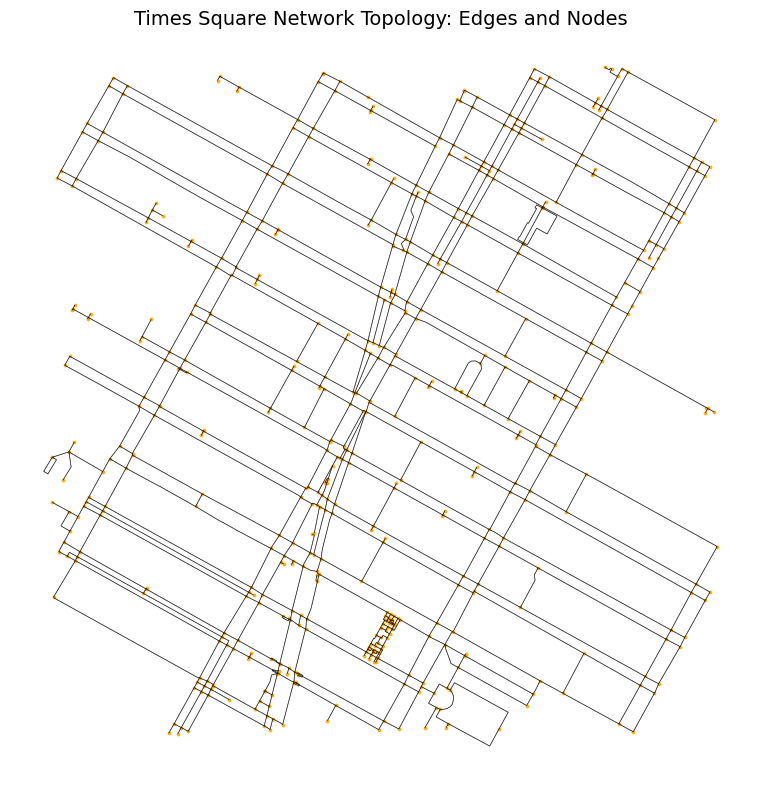

In [39]:
center_point = (40.7580, -73.9851)
G_ts = ox.graph_from_point(center_point, dist=500, network_type="walk")

nodes, edges = ox.graph_to_gdfs(G_ts)

fig, ax = plt.subplots(figsize=(8, 8))

edges.plot(ax=ax, color="black", linewidth=0.5, alpha=0.6)

nodes.plot(ax=ax, color="orange", markersize=3, alpha=0.8)

ax.set_title("Times Square Network Topology: Edges and Nodes", fontsize=14)
ax.set_axis_off()
plt.tight_layout()
plt.show()

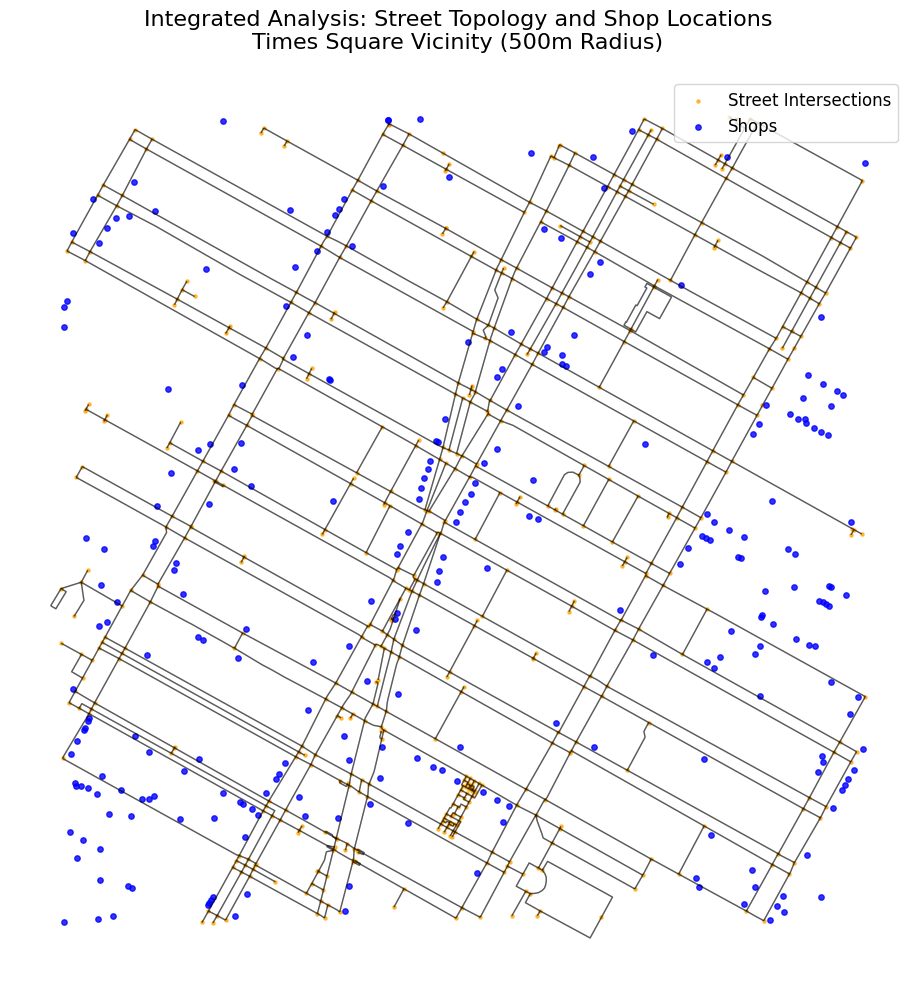

In [40]:
center_point = (40.7580, -73.9851)
G_ts = ox.graph_from_point(center_point, dist=500, network_type="walk")

nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_ts)

tags = {"shop": True}
shops_gdf = ox.features_from_point(center_point, tags=tags, dist=500)

shops_gdf = shops_gdf[shops_gdf.geometry.type == "Point"]

fig, ax = plt.subplots(figsize=(10, 10))

edges_gdf.plot(ax=ax, color="black", linewidth=1, alpha=0.4)

nodes_gdf.plot(
    ax=ax, color="orange", markersize=5, alpha=0.7, label="Street Intersections"
)

shops_gdf.plot(ax=ax, color="blue", markersize=15, alpha=0.8, label="Shops")

ax.set_title(
    "Integrated Analysis: Street Topology and Shop Locations\nTimes Square Vicinity (500m Radius)",
    fontsize=16,
    pad=20,
)

ax.legend(loc="upper right", frameon=True, fontsize=12)

ax.set_axis_off()

plt.tight_layout()
plt.show()

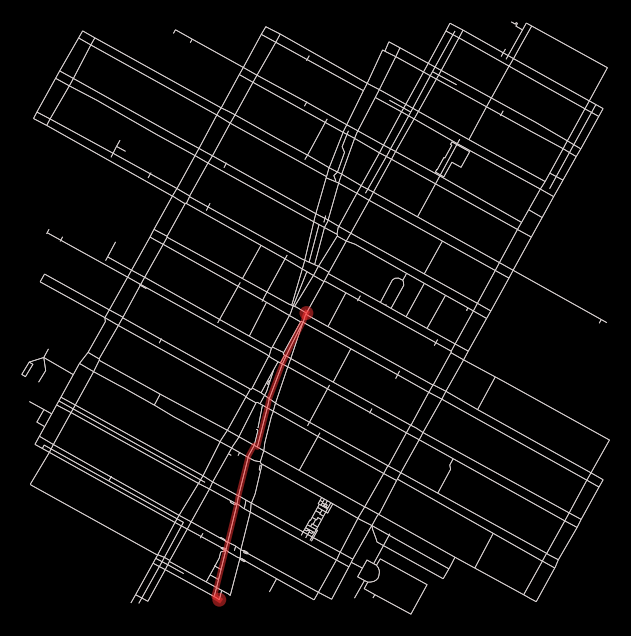

(<Figure size 800x800 with 1 Axes>, <Axes: >)

In [47]:
origin_lat_lon = (40.7580, -73.9851)
dest_lat_lon = (40.7501, -73.9875)

orig = ox.distance.nearest_nodes(G_ts, X=origin_lat_lon[1], Y=origin_lat_lon[0])
dest = ox.distance.nearest_nodes(G_ts, X=dest_lat_lon[1], Y=dest_lat_lon[0])

route = ox.shortest_path(G_ts, orig, dest, weight="length")

fig, ax = plt.subplots(figsize=(8, 8), facecolor="black")
ax.set_facecolor("black")

ox.plot_graph(
    G_ts,
    ax=ax,
    node_size=0,
    edge_color="#DAD3D3",
    edge_linewidth=0.6,
    show=False,
    close=False,
)

ox.plot_graph_route(
    G_ts,
    route,
    ax=ax,
    route_color="#ff3333",
    route_linewidth=4,
    node_size=0,
    show=True,
    close=True,
)

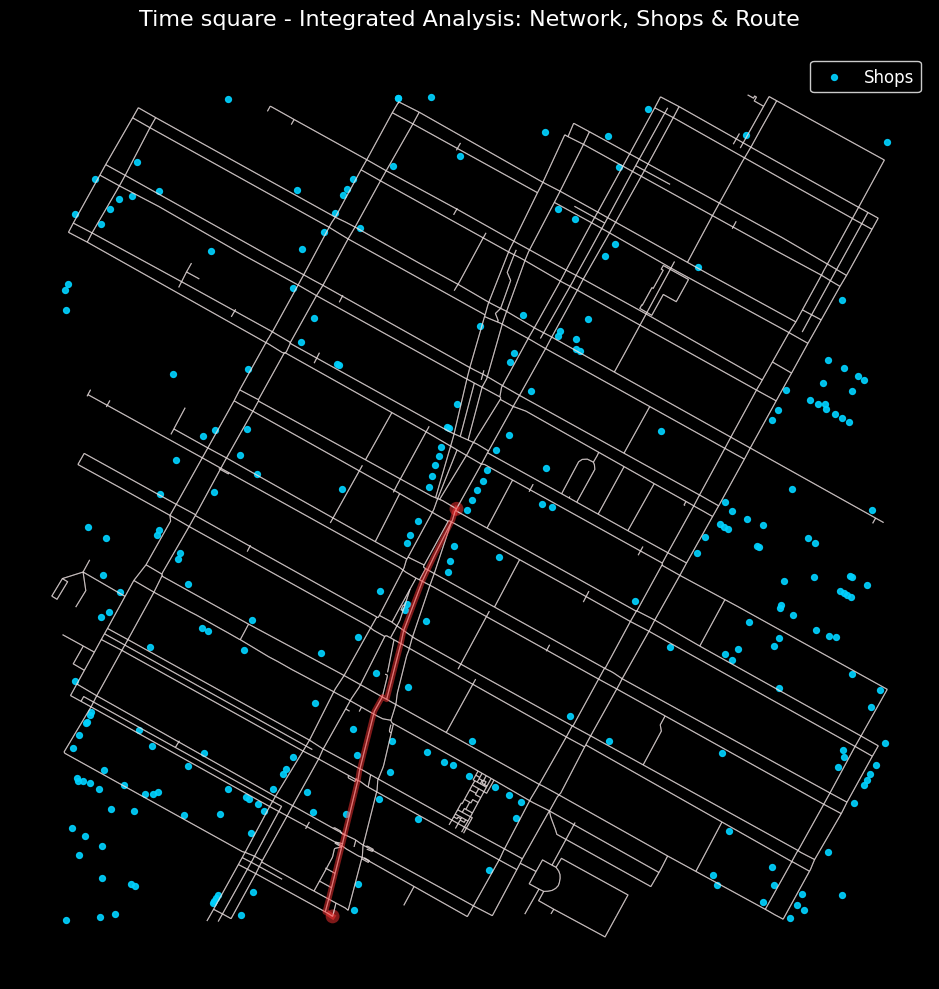

In [49]:
center_point = (40.7580, -73.9851)
G_ts = ox.graph_from_point(center_point, dist=500, network_type="walk")
nodes_gdf, edges_gdf = ox.graph_to_gdfs(G_ts)

tags = {"shop": True}
shops_gdf = ox.features_from_point(center_point, tags=tags, dist=500)
shops_gdf = shops_gdf[shops_gdf.geometry.type == "Point"]

origin_lat_lon = (40.7580, -73.9851)
dest_lat_lon = (40.7501, -73.9875)
orig = ox.distance.nearest_nodes(G_ts, X=origin_lat_lon[1], Y=origin_lat_lon[0])
dest = ox.distance.nearest_nodes(G_ts, X=dest_lat_lon[1], Y=dest_lat_lon[0])
route = ox.shortest_path(G_ts, orig, dest, weight="length")

fig, ax = plt.subplots(figsize=(10, 10), facecolor="black")
ax.set_facecolor("black")

edges_gdf.plot(ax=ax, color="#EBE0E0", linewidth=0.8, alpha=0.6)

shops_gdf.plot(ax=ax, color="#00d2ff", markersize=18, alpha=0.9, label="Shops")

ox.plot_graph_route(
    G_ts,
    route,
    ax=ax,
    route_color="#ff3333",
    route_linewidth=4,
    node_size=0,
    show=False,
    close=False,
)
ax.set_title(
    "Time square - Integrated Analysis: Network, Shops & Route",
    fontsize=16,
    color="white",
    pad=20,
)
ax.legend(
    loc="upper right",
    frameon=True,
    facecolor="black",
    edgecolor="white",
    labelcolor="white",
    fontsize=12,
)
ax.set_axis_off()

plt.tight_layout()
plt.show()